# Chapter 116 — Bézier Curves

> **Prerequisites:** ch095 (Interpolation), ch107 (Parametric Curves)
>
> **Outcomes:** Derive Bézier curves via de Casteljau's algorithm; Implement quadratic and cubic Bézier; Understand the control polygon; Connect to font rendering and animation


## De Casteljau's Algorithm

A **Bézier curve** of degree n is defined by n+1 **control points** P₀, P₁, ..., Pₙ.

**De Casteljau's algorithm:** Recursively lerp between control points at parameter t ∈ [0,1].

For cubic Bézier (4 points P₀, P₁, P₂, P₃):
Level 1: Q₀=lerp(P₀,P₁,t), Q₁=lerp(P₁,P₂,t), Q₂=lerp(P₂,P₃,t)
Level 2: R₀=lerp(Q₀,Q₁,t), R₁=lerp(Q₁,Q₂,t)
Level 3: B(t) = lerp(R₀,R₁,t)

**Explicit formula (cubic):**
B(t) = (1-t)³P₀ + 3t(1-t)²P₁ + 3t²(1-t)P₂ + t³P₃

These weights (1-t)³, 3t(1-t)², 3t²(1-t), t³ are the **Bernstein basis polynomials**.

**Properties:**
- Curve passes through P₀ (t=0) and P₃ (t=1); not through interior control points
- Curve lies within the convex hull of control points
- Tangent at P₀ points along P₀→P₁ direction; at P₃ along P₂→P₃

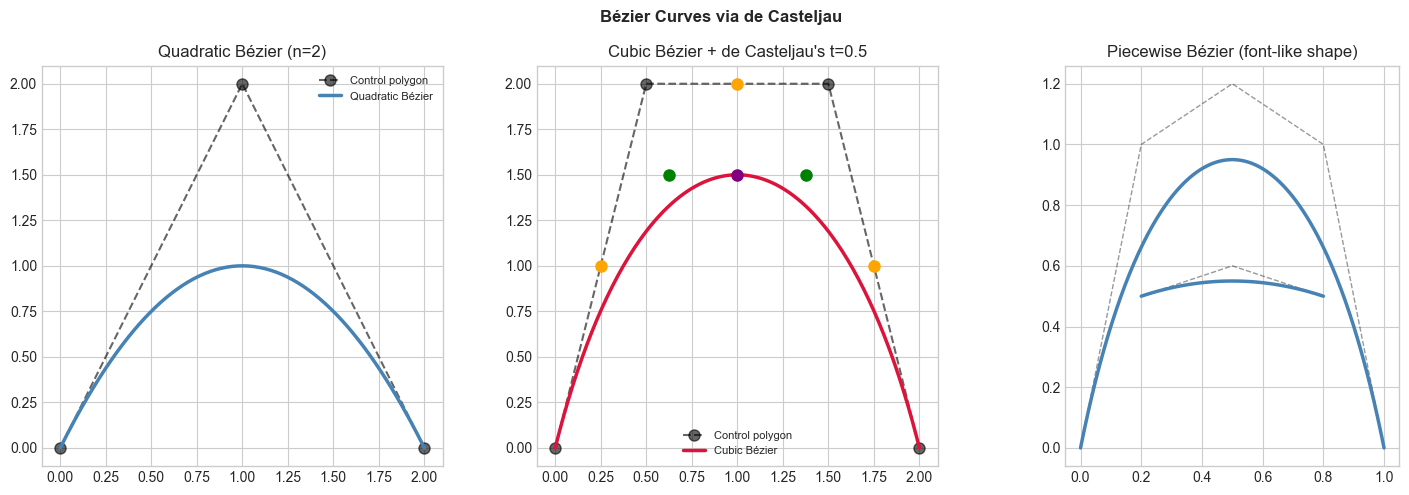

In [1]:
# --- Bézier curve implementation ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def lerp(a, b, t):
    return (1-t)*np.asarray(a) + t*np.asarray(b)

def de_casteljau(control_pts, t):
    """Evaluate Bézier curve at parameter t via de Casteljau's algorithm."""
    pts = [np.asarray(p, dtype=float) for p in control_pts]
    while len(pts) > 1:
        pts = [lerp(pts[i], pts[i+1], t) for i in range(len(pts)-1)]
    return pts[0]

def bezier_curve(control_pts, n=200):
    """Compute n points on the Bézier curve."""
    t_vals = np.linspace(0, 1, n)
    return np.array([de_casteljau(control_pts, t) for t in t_vals])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Quadratic Bezier (3 control points)
P_quad = [(0,0),(1,2),(2,0)]
curve_q = bezier_curve(P_quad)
ctrls_q = np.array(P_quad)
axes[0].plot(ctrls_q[:,0], ctrls_q[:,1], 'k--o', lw=1.5, ms=8, alpha=0.6, label='Control polygon')
axes[0].plot(curve_q[:,0], curve_q[:,1], 'steelblue', lw=2.5, label='Quadratic Bézier')
axes[0].set_title('Quadratic Bézier (n=2)'); axes[0].legend(fontsize=8); axes[0].set_aspect('equal')

# Cubic Bezier (4 control points)
P_cub = [(0,0),(0.5,2),(1.5,2),(2,0)]
curve_c = bezier_curve(P_cub)
ctrls_c = np.array(P_cub)
axes[1].plot(ctrls_c[:,0], ctrls_c[:,1], 'k--o', lw=1.5, ms=8, alpha=0.6, label='Control polygon')
axes[1].plot(curve_c[:,0], curve_c[:,1], 'crimson', lw=2.5, label='Cubic Bézier')
# Show intermediate points at t=0.5
t05 = 0.5
pts_l1 = [lerp(P_cub[i],P_cub[i+1],t05) for i in range(3)]
pts_l2 = [lerp(pts_l1[i],pts_l1[i+1],t05) for i in range(2)]
pts_l3 = [lerp(pts_l2[0],pts_l2[1],t05)]
for pts, color in [(np.array(pts_l1),'orange'),(np.array(pts_l2),'green'),
                   (np.array(pts_l3),'purple')]:
    axes[1].plot(pts[:,0] if pts.ndim>1 else [pts[0]], pts[:,1] if pts.ndim>1 else [pts[1]],
                'o', color=color, ms=8)
axes[1].set_title("Cubic Bézier + de Casteljau's t=0.5"); axes[1].legend(fontsize=8); axes[1].set_aspect('equal')

# Complex Bézier path (font-like letter)
paths = [
    [(0,0),(0.2,1),(0.5,1.2),(0.8,1),(1,0)],
    [(0.2,0.5),(0.5,0.6),(0.8,0.5)],
]
for path in paths:
    curve = bezier_curve(path)
    axes[2].plot(np.array(path)[:,0], np.array(path)[:,1], 'k--', lw=1, alpha=0.4)
    axes[2].plot(curve[:,0], curve[:,1], 'steelblue', lw=2.5)
axes[2].set_aspect('equal'); axes[2].set_title('Piecewise Bézier (font-like shape)')

plt.suptitle('Bézier Curves via de Casteljau', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

- Bézier curve: smooth parametric curve defined by control polygon
- De Casteljau: recursive lerp — elegant, numerically stable
- Cubic Bézier has 4 control points; used in PostScript, TrueType fonts, SVG, animation
- Bernstein polynomials: basis for the curve; sum to 1 for all t (partition of unity)

**Forward:** ch117 (Splines) connects multiple Bézier segments; the smooth joining condition requires matching tangent vectors.